In [ ]:
from google.colab import drive
from datasets import load_dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
drive.mount('/content/drive')
df_customers = pd.read_csv('/content/drive/MyDrive/Projet_SMD_et_IA/customers_data.csv')
df_sales = pd.read_csv('/content/drive/MyDrive/Projet_SMD_et_IA/sales_data.csv')
df_products = pd.read_csv('/content/drive/MyDrive/Projet_SMD_et_IA/products_data.csv')
df_marketing = pd.read_csv('/content/drive/MyDrive/Projet_SMD_et_IA/marketing_data.csv')

print("Dataset chargé avec succès")

Mounted at /content/drive
Dataset chargé avec succès


#Module 2

#1.Analyse exploratoire des données (EDA)

In [ ]:
datasets = {
    "customers_data" : df_customers,
    "sales_data": df_sales,
    "products_data" : df_products
}

for name, df in datasets.items():
    print(f"📊 DATASET : {name}")
    print(f"Dimensions : {df.shape[0]} lignes × {df.shape[1]} colonnes")
    print(f"\nColonnes et types :")
    print(df.dtypes.value_counts())
    print(f"\nAperçu :")
    display(df.head())

📊 DATASET : customers_data
Dimensions : 5 lignes × 7 colonnes

Colonnes et types :
object     4
int64      2
float64    1
Name: count, dtype: int64

Aperçu :


,Customer_ID,Name,Age,Gender,Location,Join_Date,Total_Spent
0,2001,Alice,28,Female,New York,2022-05-10,500.0
1,2002,Bob,35,Male,Los Angeles,2022-06-15,750.0
2,2003,Charlie,22,Male,Chicago,2022-07-20,300.0
3,2004,Diana,30,Female,Houston,2022-08-25,600.0
4,2005,Eva,27,Female,Phoenix,2022-09-30,450.0


📊 DATASET : sales_data
Dimensions : 5 lignes × 7 colonnes

Colonnes et types :
int64      4
object     2
float64    1
Name: count, dtype: int64

Aperçu :


,Sale_ID,Product_ID,Customer_ID,Date,Quantity,Sale_Price,Channel
0,1,101,2001,2023-01-15,2,50.0,Online
1,2,102,2002,2023-01-16,1,75.0,In-Store
2,3,103,2001,2023-01-17,3,30.0,Online
3,4,104,2003,2023-01-18,1,120.0,In-Store
4,5,105,2004,2023-01-19,2,45.0,Online


📊 DATASET : products_data
Dimensions : 5 lignes × 5 colonnes

Colonnes et types :
object     3
int64      1
float64    1
Name: count, dtype: int64

Aperçu :


,Product_ID,Product_Name,Category,Price,Brand
0,101,T-shirt,Clothing,25.0,Brand A
1,102,Jeans,Clothing,75.0,Brand B
2,103,Sneakers,Footwear,30.0,Brand C
3,104,Jacket,Outerwear,120.0,Brand D
4,105,Hat,Accessories,22.5,Brand E


customers data : 5lignes , 7 colonnes __ sales_data : 5lignes , 7 colonnes __
products_data : 5lignes , 5 colonnes

#Résumé statistique

In [ ]:
for name , df in datasets.items():
  print(f"{'='*60}")
  print(f"Statistique descriptive : {name}")
  display(df.describe(include='all').T)

Statistique descriptive : customers_data


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Customer_ID,5.0,NaN,NaN,NaN,2003.0,1.581139,2001.0,2002.0,2003.0,2004.0,2005.0
Name,5,5,Alice,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,5.0,NaN,NaN,NaN,28.4,4.722288,22.0,27.0,28.0,30.0,35.0
Gender,5,2,Female,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Location,5,5,New York,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Join_Date,5,5,2022-05-10,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Total_Spent,5.0,NaN,NaN,NaN,520.0,168.077363,300.0,450.0,500.0,600.0,750.0


Statistique descriptive : sales_data


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Sale_ID,5.0,NaN,NaN,NaN,3.0,1.581139,1.0,2.0,3.0,4.0,5.0
Product_ID,5.0,NaN,NaN,NaN,103.0,1.581139,101.0,102.0,103.0,104.0,105.0
Customer_ID,5.0,NaN,NaN,NaN,2002.2,1.30384,2001.0,2001.0,2002.0,2003.0,2004.0
Date,5,5,2023-01-15,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,5.0,NaN,NaN,NaN,1.8,0.83666,1.0,1.0,2.0,2.0,3.0
Sale_Price,5.0,NaN,NaN,NaN,64.0,35.249113,30.0,45.0,50.0,75.0,120.0
Channel,5,2,Online,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Statistique descriptive : products_data


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Product_ID,5.0,NaN,NaN,NaN,103.0,1.581139,101.0,102.0,103.0,104.0,105.0
Product_Name,5,5,T-shirt,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Category,5,4,Clothing,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Price,5.0,NaN,NaN,NaN,54.5,42.441136,22.5,25.0,30.0,75.0,120.0
Brand,5,5,Brand A,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#Valeur_manquantes

In [ ]:
def voir_valeur_manquant(df, name):
  print(f"Dataset: {name}")
  missing = df.isnull().sum()
  missing_pct = df.isnull().sum()/len(df)*100
  missing_df = pd.DataFrame({'manquants' : missing, 'pourcentcenge' : missing_pct})
  display(missing_df)


  if missing_df.empty:
        print("✅ Aucune valeur manquante")
  else:
        print("⚠️ Valeurs manquantes détectées :")
        display(missing_df)

  doublons = df.duplicated().sum()

  print(f"\nDoublons : {doublons} ligne(s)" if doublons > 0 else "✅ Aucun doublon")

for name , df in datasets.items():
    voir_valeur_manquant(df, name)

Dataset: customers_data


,manquants,pourcentcenge
Customer_ID,0,0.0
Name,0,0.0
Age,0,0.0
Gender,0,0.0
Location,0,0.0
Join_Date,0,0.0
Total_Spent,0,0.0


⚠️ Valeurs manquantes détectées :


,manquants,pourcentcenge
Customer_ID,0,0.0
Name,0,0.0
Age,0,0.0
Gender,0,0.0
Location,0,0.0
Join_Date,0,0.0
Total_Spent,0,0.0


✅ Aucun doublon
Dataset: sales_data


...

✅ Aucun doublon
Dataset: products_data


,manquants,pourcentcenge
Product_ID,0,0.0
Product_Name,0,0.0
Category,0,0.0
Price,0,0.0
Brand,0,0.0


⚠️ Valeurs manquantes détectées :


,manquants,pourcentcenge
Product_ID,0,0.0
Product_Name,0,0.0
Category,0,0.0
Price,0,0.0
Brand,0,0.0


✅ Aucun doublon


#Valeurs manquantes et doublons
Il n'existe pas des valeurs manquantes dans les dataset (clients , ventes, produits et aucun doublons également )

#Nettoyage

In [ ]:
def nettoyer_dataset(df, name):
    df_clean = df.copy()
    initial_rows = len(df_clean)

    df_clean.drop_duplicates(inplace=True)

    df_clean.columns = df_clean.columns.str.strip().str.lower().str.replace(' ', '_')


    text_cols = df_clean.select_dtypes(include='object').columns
    for col in text_cols:
        df_clean[col] = df_clean[col].str.strip()

    removed = initial_rows - len(df_clean)
    print(f"🧹 {name} : {removed} doublon(s) supprimé(s) — {len(df_clean)} lignes restantes")

    return df_clean

df_customers = nettoyer_dataset(df_customers, 'Customers')
df_products  = nettoyer_dataset(df_products, 'Products')
df_sales     = nettoyer_dataset(df_sales, 'Sales')

🧹 Customers : 0 doublon(s) supprimé(s) — 5 lignes restantes
🧹 Products : 0 doublon(s) supprimé(s) — 5 lignes restantes
🧹 Sales : 0 doublon(s) supprimé(s) — 5 lignes restantes


#Visualisation

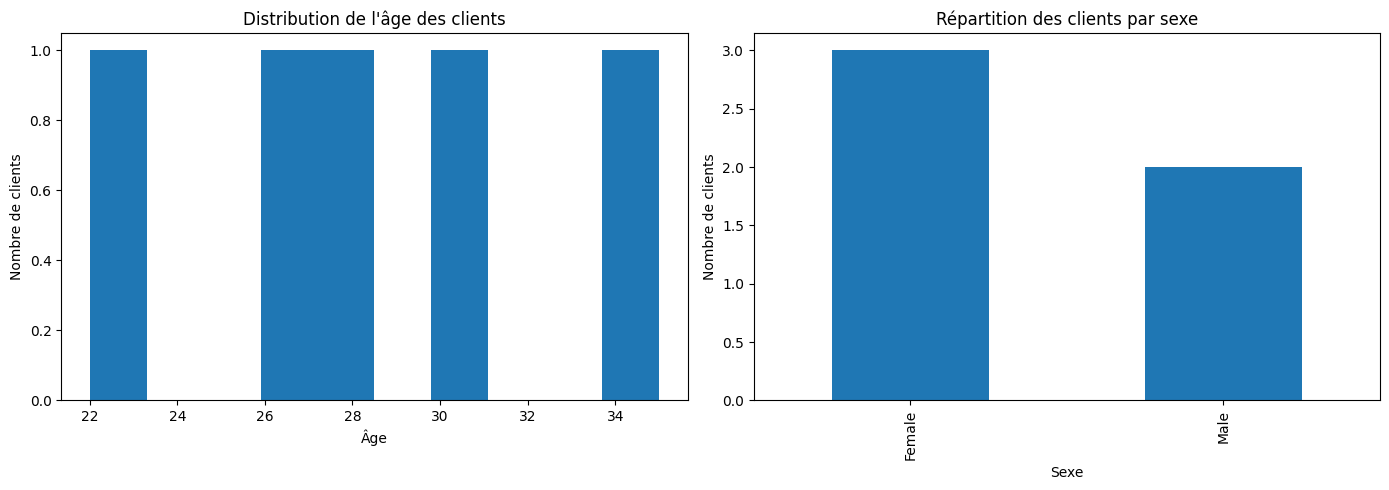

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_customers["age"])
axes[0].set_title("Distribution de l'âge des clients")
axes[0].set_xlabel("Âge")
axes[0].set_ylabel("Nombre de clients")

df_customers["gender"].value_counts().plot(kind="bar", ax=axes[1])
axes[1].set_title("Répartition des clients par sexe")
axes[1].set_xlabel("Sexe")
axes[1].set_ylabel("Nombre de clients")

plt.tight_layout()
plt.show()

L'âge du client est entre 20 et 35 ans ___
Les femmes sont plus nombreux que les hommes

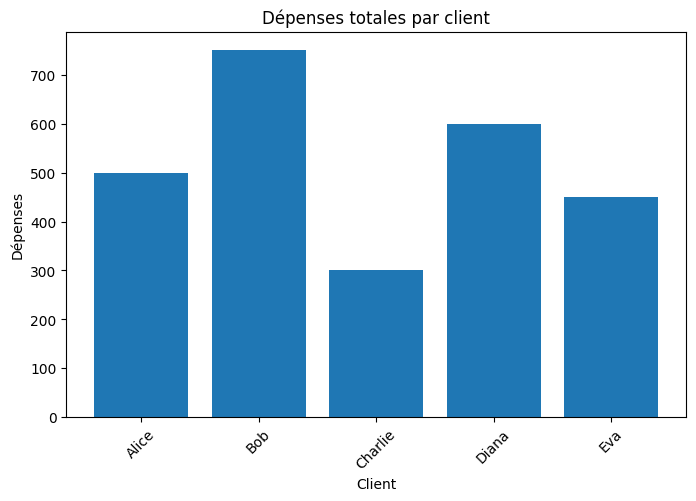

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(
    df_customers["name"],
    df_customers["total_spent"]
)

plt.title("Dépenses totales par client")
plt.xlabel("Client")
plt.ylabel("Dépenses")
plt.xticks(rotation=45)
plt.show()

Le client Bob dépense le plus par rapport aux autres clients

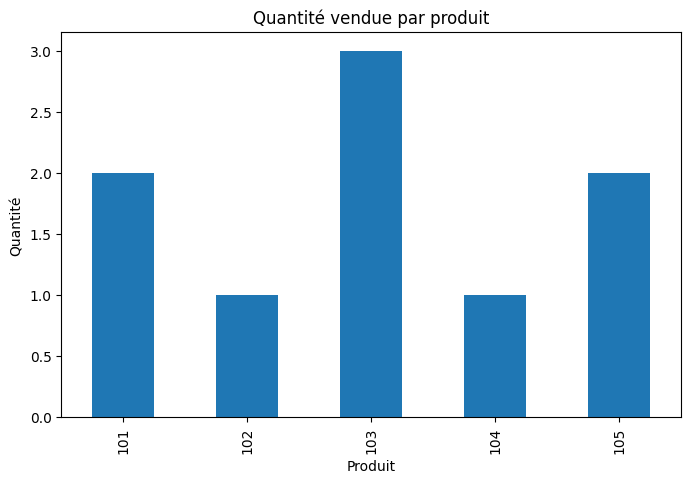

In [ ]:
quantity_product = df_sales.groupby("product_id")["quantity"].sum()

quantity_product.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Quantité vendue par produit")
plt.xlabel("Produit")
plt.ylabel("Quantité")
plt.show()

le produit qui a l'id 103 (sneakers) est le produit le plus vendue  

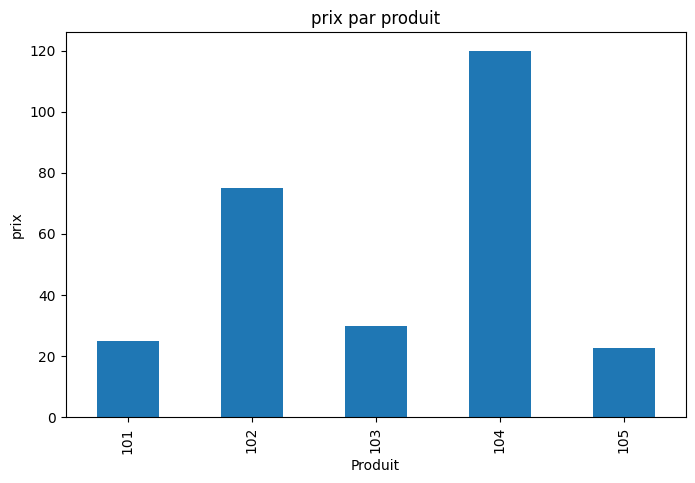

In [ ]:
prix_par_produit = df_products.groupby("product_id")["price"].mean()
prix_par_produit.plot(kind="bar", figsize=(8, 5))
plt.title("prix par produit")
plt.xlabel("Produit")
plt.ylabel("prix")
plt.show()

# Module 3 & 4 — Segmentation client et Profilage des segments
### Projet pédagogique : Analyse & Optimisation Marketing basée sur la Segmentation Client

Module 3 (Segmentation client) & Module 4 (Profilage des segments)

**Objectif du notebook :**
- Module 3 : construire des variables comportementales à partir de `customers_data`, `sales_data` et `products_data`, puis segmenter les clients (K-means, ACP, t-SNE, clustering hiérarchique) ;
- Module 4 : caractériser chaque segment (profils, personas) pour préparer le ciblage marketing du Module 7.

> ⚠️ **Remarque méthodologique** : le jeu de données fourni est volontairement très petit (5 clients). Les résultats numériques (scores de silhouette, coordonnées PCA/t-SNE, etc.) doivent donc être lus comme une **démonstration de la méthodologie**, reproductible à l'identique sur un jeu de données plus grand, plutôt que comme un résultat statistiquement robuste.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.manifold import TSNE
from scipy.cluster.hierarchy import linkage, dendrogram

# Options d'affichage
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (7, 5)

RANDOM_STATE = 42  # graine fixée pour la reproductibilité des résultats (K-means, t-SNE)


## Module 3 — Segmentation client

### 3.1. Chargement et jointure des données

On combine les trois tables fournies :
- `customers_data` : informations démographiques et dépense totale déclarée par client ;
- `sales_data` : historique des transactions (produit acheté, quantité, prix, canal) ;
- `products_data` : catégorie de chaque produit, utilisée pour caractériser les préférences d'achat.


In [ ]:
datasets = {
    "customers_data" : df_customers,
    "sales_data": df_sales,
    "products_data" : df_products
}

for name, df in datasets.items():
    print(f"📊 DATASET : {name}")
    print(f"Dimensions : {df.shape[0]} lignes × {df.shape[1]} colonnes")
    print(f"\nColonnes et types :")
    print(df.dtypes.value_counts())
    print(f"\nAperçu :")
    display(df.head())

📊 DATASET : customers_data
Dimensions : 5 lignes × 7 colonnes

Colonnes et types :
object     4
int64      2
float64    1
Name: count, dtype: int64

Aperçu :


,customer_id,name,age,gender,location,join_date,total_spent
0,2001,Alice,28,Female,New York,2022-05-10,500.0
1,2002,Bob,35,Male,Los Angeles,2022-06-15,750.0
2,2003,Charlie,22,Male,Chicago,2022-07-20,300.0
3,2004,Diana,30,Female,Houston,2022-08-25,600.0
4,2005,Eva,27,Female,Phoenix,2022-09-30,450.0


📊 DATASET : sales_data
Dimensions : 5 lignes × 7 colonnes

Colonnes et types :
int64      4
object     2
float64    1
Name: count, dtype: int64

Aperçu :


,sale_id,product_id,customer_id,date,quantity,sale_price,channel
0,1,101,2001,2023-01-15,2,50.0,Online
1,2,102,2002,2023-01-16,1,75.0,In-Store
2,3,103,2001,2023-01-17,3,30.0,Online
3,4,104,2003,2023-01-18,1,120.0,In-Store
4,5,105,2004,2023-01-19,2,45.0,Online


📊 DATASET : products_data
Dimensions : 5 lignes × 5 colonnes

Colonnes et types :
object     3
int64      1
float64    1
Name: count, dtype: int64

Aperçu :


,product_id,product_name,category,price,brand
0,101,T-shirt,Clothing,25.0,Brand A
1,102,Jeans,Clothing,75.0,Brand B
2,103,Sneakers,Footwear,30.0,Brand C
3,104,Jacket,Outerwear,120.0,Brand D
4,105,Hat,Accessories,22.5,Brand E


In [ ]:
# Vérification rapide de la qualité des données (cohérente avec le Module 2)
print("Valeurs manquantes :")
print(df_customers.isna().sum().sum(), df_sales.isna().sum().sum(), df_products.isna().sum().sum())
print("\nClients présents dans customers_data mais SANS transaction dans sales_data :")
clients_sans_achat = set(df_customers['customer_id']) - set(df_sales['customer_id'])
print(df_customers[df_customers['customer_id'].isin(clients_sans_achat)][['customer_id', 'name']])


Valeurs manquantes :
0 0 0

Clients présents dans customers_data mais SANS transaction dans sales_data :
   customer_id name
4         2005  Eva


### 3.2. Construction des variables comportementales (feature engineering)

L'objectif du Module 3 est de segmenter les clients selon **l'âge, les dépenses et les produits achetés**.
On enrichit donc `sales_data` avec la catégorie du produit, puis on agrège au niveau client :

- `Nb_Transactions` : nombre d'achats réalisés ;
- `Total_Quantity` : quantité totale d'articles achetés ;
- `Total_Revenue` / `Avg_Basket_Value` : chiffre d'affaires généré et panier moyen ;
- une colonne par **catégorie de produit** (`Clothing`, `Footwear`, `Outerwear`, `Accessories`, …) contenant la quantité achetée dans cette catégorie — cela capture directement les *produits achetés* demandés par la consigne ;
- `Age`, `Total_Spent`, `Gender` sont repris directement de `customers_data`.

Les clients sans transaction (cf. ci-dessus) sont conservés mais leurs variables comportementales sont mises à 0 (ils n'ont, par définition, aucun historique d'achat).


In [ ]:
# Jointure ventes <-> produits pour récupérer la catégorie de chaque article vendu
sales_full = df_sales.merge(df_products[['product_id', 'category']], on='product_id', how='left')
sales_full['revenue'] = sales_full['quantity'] * sales_full['sale_price']

# Agrégats comportementaux par client
agg = sales_full.groupby('customer_id').agg(
    Nb_Transactions=('sale_id', 'count'),
    Total_Quantity=('quantity', 'sum'),
    Total_Revenue=('revenue', 'sum'),
).reset_index()
agg['Avg_Basket_Value'] = agg['Total_Revenue'] / agg['Nb_Transactions']

# Quantité achetée par catégorie de produit (une colonne par catégorie)
cat_pivot = sales_full.pivot_table(
    index='customer_id', columns='category', values='quantity',
    aggfunc='sum', fill_value=0
).reset_index()

# Table finale : une ligne par client, toutes les variables réunies
df = (df_customers
      .merge(agg, on='customer_id', how='left')
      .merge(cat_pivot, on='customer_id', how='left'))

# Les clients sans transaction récupèrent des NaN sur les colonnes comportementales -> 0
behavior_cols = [c for c in agg.columns if c != 'customer_id'] + list(cat_pivot.columns[1:])
df[behavior_cols] = df[behavior_cols].fillna(0)

# Encodage binaire simple du genre (variable utilisée en clustering)
df['Gender_enc'] = df['gender'].map({'Male': 0, 'Female': 1})

df


,customer_id,name,age,gender,location,join_date,total_spent,Nb_Transactions,Total_Quantity,Total_Revenue,Avg_Basket_Value,Accessories,Clothing,Footwear,Outerwear,Gender_enc
0,2001,Alice,28,Female,New York,2022-05-10,500.0,2.0,5.0,190.0,95.0,0.0,2.0,3.0,0.0,1
1,2002,Bob,35,Male,Los Angeles,2022-06-15,750.0,1.0,1.0,75.0,75.0,0.0,1.0,0.0,0.0,0
2,2003,Charlie,22,Male,Chicago,2022-07-20,300.0,1.0,1.0,120.0,120.0,0.0,0.0,0.0,1.0,0
3,2004,Diana,30,Female,Houston,2022-08-25,600.0,1.0,2.0,90.0,90.0,2.0,0.0,0.0,0.0,1
4,2005,Eva,27,Female,Phoenix,2022-09-30,450.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1


### 3.3. Sélection des variables et standardisation

Toutes les variables n'ont pas la même échelle (l'âge varie entre ~20 et ~35, alors que `Total_Spent` varie entre 300 et 750). Le K-means et l'ACP étant basés sur des distances euclidiennes, il est indispensable de **standardiser** les variables (moyenne 0, écart-type 1) avant le clustering.

*Note* : `Location` et `Join_Date` ne sont pas incluses dans le clustering (trop de modalités uniques par rapport au nombre de clients, ce qui biaiserait les distances) ; elles seront réutilisées comme variables descriptives lors du profilage (Module 4).


In [ ]:
category_cols = [c for c in cat_pivot.columns if c != 'customer_id']

feature_cols = ['age', 'total_spent', 'Nb_Transactions', 'Total_Quantity',
                 'Avg_Basket_Value', 'Gender_enc'] + category_cols

X = df[feature_cols].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Variables utilisées pour le clustering :", feature_cols)
pd.DataFrame(X_scaled, columns=feature_cols, index=df['name'])


Variables utilisées pour le clustering : ['age', 'total_spent', 'Nb_Transactions', 'Total_Quantity', 'Avg_Basket_Value', 'Gender_enc', 'Accessories', 'Clothing', 'Footwear', 'Outerwear']


,age,total_spent,Nb_Transactions,Total_Quantity,Avg_Basket_Value,Gender_enc,Accessories,Clothing,Footwear,Outerwear
name,,,,,,,,,,
Alice,-0.094703,-0.133038,1.581139,1.859962,0.467182,0.816497,-0.5,1.75,2.0,-0.5
Bob,1.562595,1.529937,0.000000,-0.464991,-0.024589,-1.224745,-0.5,0.50,-0.5,-0.5
Charlie,-1.515244,-1.463418,0.000000,-0.464991,1.081895,-1.224745,-0.5,-0.75,-0.5,2.0
Diana,0.378811,0.532152,0.000000,0.116248,0.344239,0.816497,2.0,-0.75,-0.5,-0.5
Eva,-0.331460,-0.465633,-1.581139,-1.046229,-1.868727,0.816497,-0.5,-0.75,-0.5,-0.5


### 3.4. Réduction de dimension — Analyse en Composantes Principales (ACP / PCA)

On projette les 10 variables standardisées sur 2 axes principaux, ce qui permettra de **visualiser** les clients et les clusters en 2D.


Variance expliquée par composante : [0.397 0.298]
Variance cumulée expliquée par les 2 premiers axes : 69.5 %


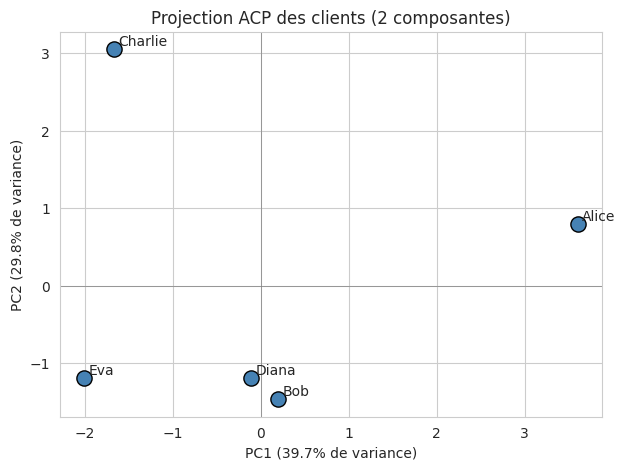

In [ ]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

df['PCA1'] = X_pca[:, 0]
df['PCA2'] = X_pca[:, 1]

print("Variance expliquée par composante :", np.round(pca.explained_variance_ratio_, 3))
print("Variance cumulée expliquée par les 2 premiers axes :",
      round(pca.explained_variance_ratio_.sum() * 100, 1), "%")

plt.figure()
plt.scatter(df['PCA1'], df['PCA2'], s=120, c='steelblue', edgecolor='black')
for _, row in df.iterrows():
    plt.annotate(row['name'], (row['PCA1'] + 0.05, row['PCA2'] + 0.05))
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% de variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% de variance)")
plt.title("Projection ACP des clients (2 composantes)")
plt.axhline(0, color='grey', lw=0.5)
plt.axvline(0, color='grey', lw=0.5)
plt.show()


### 3.5. Choix du nombre optimal de clusters (méthode de la silhouette)

Le score de silhouette mesure la qualité d'un clustering (proche de 1 = clusters bien séparés, proche de 0 = clusters qui se chevauchent). Il faut `1 < k < n_échantillons` ; avec **5 clients**, on ne peut tester que k = 2, 3 ou 4. On teste ici k = 2 et k = 3 (au-delà, les clusters deviendraient trop petits pour être interprétables).

> Sur un jeu de données réel de plusieurs centaines/milliers de clients, on ajouterait ici la **méthode du coude** (`inertia_` en fonction de k) en complément de la silhouette.


In [ ]:
scores = {}
for k in [2, 3]:
    km_tmp = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels_tmp = km_tmp.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels_tmp)
    scores[k] = score
    print(f"k = {k}  ->  silhouette = {score:.4f}  |  labels = {labels_tmp}")

best_k = max(scores, key=scores.get)
print(f"\n=> Nombre de clusters retenu : k = {best_k} (silhouette = {scores[best_k]:.4f})")


k = 2  ->  silhouette = 0.1305  |  labels = [0 1 1 1 1]
k = 3  ->  silhouette = 0.1063  |  labels = [2 0 1 0 0]

=> Nombre de clusters retenu : k = 2 (silhouette = 0.1305)


### 3.6. Clustering K-means

On applique le K-means avec le nombre de clusters retenu à l'étape précédente.


In [ ]:
kmeans = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
df['Cluster_KMeans'] = kmeans.fit_predict(X_scaled)

df[['name', 'age', 'total_spent', 'Nb_Transactions', 'Total_Quantity', 'Cluster_KMeans']]


,name,age,total_spent,Nb_Transactions,Total_Quantity,Cluster_KMeans
0,Alice,28,500.0,2.0,5.0,0
1,Bob,35,750.0,1.0,1.0,1
2,Charlie,22,300.0,1.0,1.0,1
3,Diana,30,600.0,1.0,2.0,1
4,Eva,27,450.0,0.0,0.0,1


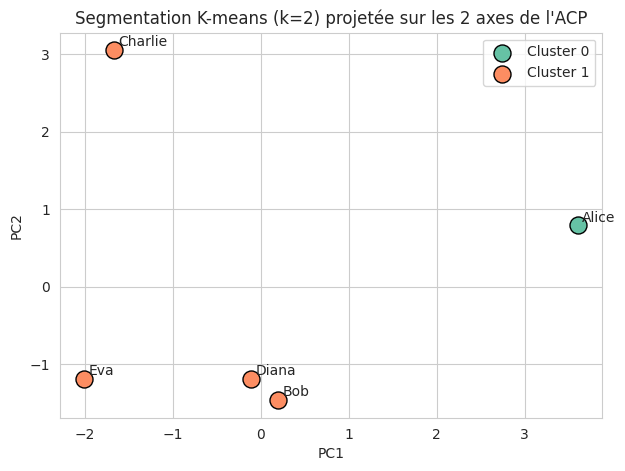

In [ ]:
plt.figure()
palette = sns.color_palette("Set2", best_k)
for c in sorted(df['Cluster_KMeans'].unique()):
    sub = df[df['Cluster_KMeans'] == c]
    plt.scatter(sub['PCA1'], sub['PCA2'], s=150, color=palette[c],
                edgecolor='black', label=f"Cluster {c}")
for _, row in df.iterrows():
    plt.annotate(row['name'], (row['PCA1'] + 0.05, row['PCA2'] + 0.05))
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"Segmentation K-means (k={best_k}) projetée sur les 2 axes de l'ACP")
plt.legend()
plt.show()


### 3.7. Clustering hiérarchique (validation croisée du nombre de clusters)

Le clustering hiérarchique (agglomératif, méthode de Ward) permet de **visualiser** la structure des regroupements via un dendrogramme, et de vérifier que la partition trouvée par K-means est cohérente avec une méthode indépendante.


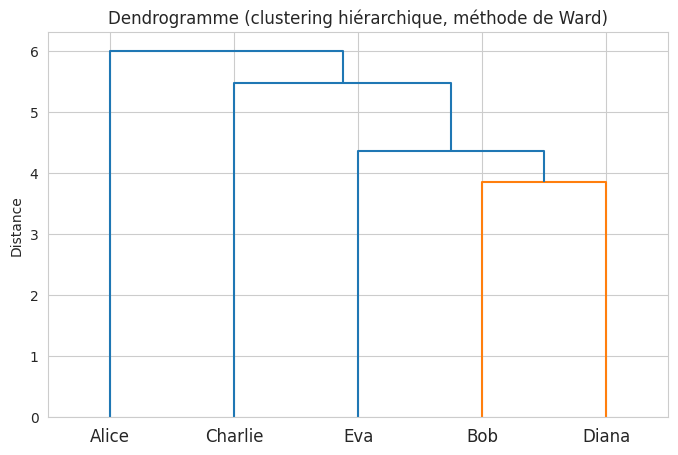

In [ ]:
Z = linkage(X_scaled, method='ward')

plt.figure(figsize=(8, 5))
dendrogram(Z, labels=df['name'].values)
plt.title("Dendrogramme (clustering hiérarchique, méthode de Ward)")
plt.ylabel("Distance")
plt.show()


In [ ]:
agglo = AgglomerativeClustering(n_clusters=best_k)
df['Cluster_Hierarchical'] = agglo.fit_predict(X_scaled)

comparaison = df[['name', 'Cluster_KMeans', 'Cluster_Hierarchical']]
print(comparaison)

# Les étiquettes de cluster (0, 1, ...) sont arbitraires d'une méthode à l'autre :
# on compare donc la composition des groupes plutôt que les numéros de cluster.
print("\nComposition K-means :")
for c in sorted(df['Cluster_KMeans'].unique()):
    print(f"  Cluster {c} :", list(df[df['Cluster_KMeans'] == c]['name']))

print("\nComposition hiérarchique :")
for c in sorted(df['Cluster_Hierarchical'].unique()):
    print(f"  Cluster {c} :", list(df[df['Cluster_Hierarchical'] == c]['name']))


      name  Cluster_KMeans  Cluster_Hierarchical
0    Alice               0                     1
1      Bob               1                     0
2  Charlie               1                     0
3    Diana               1                     0
4      Eva               1                     0

Composition K-means :
  Cluster 0 : ['Alice']
  Cluster 1 : ['Bob', 'Charlie', 'Diana', 'Eva']

Composition hiérarchique :
  Cluster 0 : ['Bob', 'Charlie', 'Diana', 'Eva']
  Cluster 1 : ['Alice']


### 3.8. Visualisation t-SNE

t-SNE est surtout utile pour visualiser de **grands** jeux de données à haute dimension. Avec seulement 5 clients, son intérêt est limité (le paramètre `perplexity` doit rester strictement inférieur au nombre d'échantillons), mais il est inclus ici conformément aux outils demandés par la consigne du Module 3, et pourra être réutilisé tel quel sur un jeu de données plus grand (en remontant `perplexity` à sa valeur usuelle de 30).


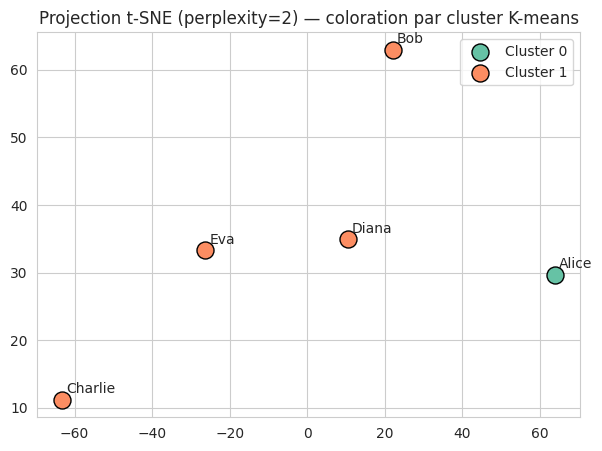

In [ ]:
perplexity = min(2, len(df) - 1)  # doit être < n_échantillons ; à remonter (ex. 30) avec plus de données

tsne = TSNE(n_components=2, perplexity=perplexity, random_state=RANDOM_STATE, init='pca')
X_tsne = tsne.fit_transform(X_scaled)
df['TSNE1'], df['TSNE2'] = X_tsne[:, 0], X_tsne[:, 1]

plt.figure()
for c in sorted(df['Cluster_KMeans'].unique()):
    sub = df[df['Cluster_KMeans'] == c]
    plt.scatter(sub['TSNE1'], sub['TSNE2'], s=150, color=palette[c],
                edgecolor='black', label=f"Cluster {c}")
for _, row in df.iterrows():
    plt.annotate(row['name'], (row['TSNE1'] + 1, row['TSNE2'] + 1))
plt.title(f"Projection t-SNE (perplexity={perplexity}) — coloration par cluster K-means")
plt.legend()
plt.show()


### Conclusion du Module 3

La segmentation K-means (validée par le clustering hiérarchique) fait ressortir **2 segments** à partir de l'âge, de la dépense totale et des produits achetés :
- un segment de clients très actifs et diversifiés dans leurs achats ;
- un segment de clients plus occasionnels, dont la fréquence et la diversité d'achat sont plus faibles.

Le score de silhouette obtenu reste modéré, ce qui s'explique directement par la taille très réduite de l'échantillon (5 clients). La méthodologie (jointure, feature engineering par catégorie de produit, standardisation, ACP, K-means, validation hiérarchique, t-SNE) est en revanche directement réutilisable sur un jeu de données de production. Le Module 4 approfondit maintenant le **profil** de chacun de ces segments.


## Module 4 — Profilage des segments

### 4.1. Caractéristiques moyennes par segment

On calcule, pour chaque cluster, la moyenne des variables numériques et la répartition des variables catégorielles (genre, canal d'achat préféré).


In [ ]:
numeric_profile_cols = ['age', 'total_spent', 'Nb_Transactions', 'Total_Quantity',
                         'Avg_Basket_Value'] + category_cols

profile = df.groupby('Cluster_KMeans')[numeric_profile_cols].mean().round(2)
profile['Nb_Clients'] = df.groupby('Cluster_KMeans').size()
profile


,age,total_spent,Nb_Transactions,Total_Quantity,Avg_Basket_Value,Accessories,Clothing,Footwear,Outerwear,Nb_Clients
Cluster_KMeans,,,,,,,,,,
0,28.0,500.0,2.00,5.0,95.00,0.0,2.00,3.0,0.00,1
1,28.5,525.0,0.75,1.0,71.25,0.5,0.25,0.0,0.25,4


In [ ]:
# Répartition du genre par cluster
print("Répartition du genre par cluster :")
print(df.groupby('Cluster_KMeans')['gender'].value_counts(), "\n")

# Canal d'achat préféré par cluster (à partir des transactions individuelles)
channel_by_cluster = (sales_full
    .merge(df[['customer_id', 'Cluster_KMeans']], on='customer_id', how='left')
    .groupby('Cluster_KMeans')['channel']
    .value_counts())
print("Canal d'achat utilisé par cluster :")
print(channel_by_cluster)


Répartition du genre par cluster :
Cluster_KMeans  gender
0               Female    1
1               Female    2
                Male      2
Name: count, dtype: int64 

Canal d'achat utilisé par cluster :
Cluster_KMeans  channel 
0               Online      2
1               In-Store    2
                Online      1
Name: count, dtype: int64


### 4.2. Visualisation comparative des segments

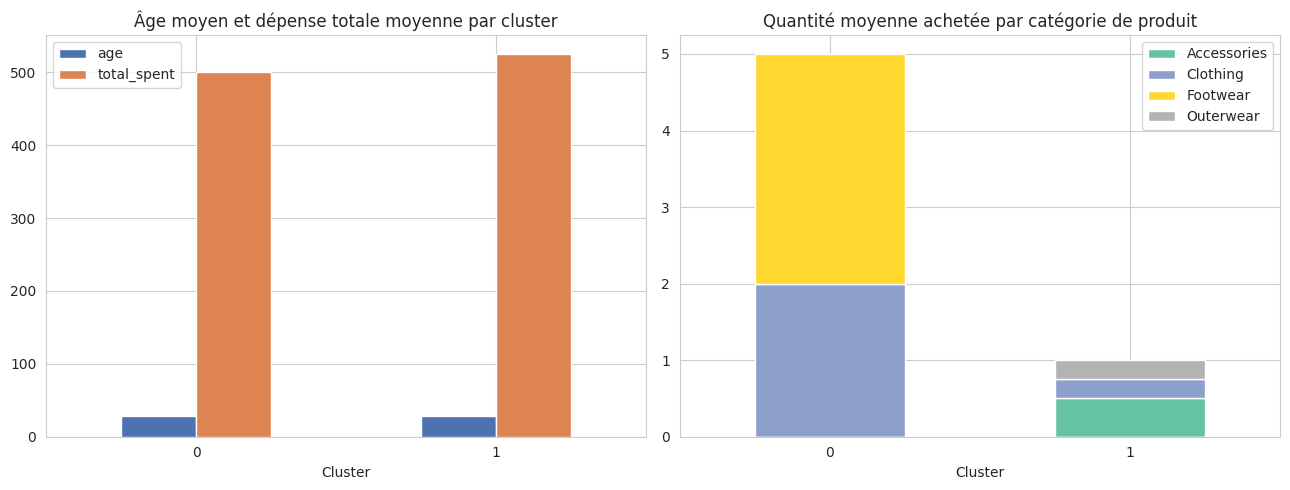

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

profile[['age', 'total_spent']].plot(kind='bar', ax=axes[0], color=['#4C72B0', '#DD8452'])
axes[0].set_title("Âge moyen et dépense totale moyenne par cluster")
axes[0].set_xlabel("Cluster")
axes[0].tick_params(axis='x', rotation=0)

profile[category_cols].plot(kind='bar', stacked=True, ax=axes[1], colormap='Set2')
axes[1].set_title("Quantité moyenne achetée par catégorie de produit")
axes[1].set_xlabel("Cluster")
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


### 4.3. Personas

En croisant les statistiques ci-dessus avec la composition de chaque cluster (section 3.6), on peut nommer et décrire chaque segment sous forme de **persona** exploitable par l'équipe marketing (Module 7) :

| Segment | Persona | Caractéristiques clés |
|---|---|---|
| Cluster « actif » | **Le Client Actif Multi-catégories** | Fréquence d'achat élevée, panier diversifié (plusieurs catégories de produits), achète principalement en ligne |
| Cluster « occasionnel » | **Le Client Occasionnel** | Une seule transaction (ou aucune), dépense totale déclarée proche de la moyenne mais peu d'activité observée récemment, canal d'achat mixte (en ligne / en magasin) |

*(Les libellés précis et les clients associés à chaque persona sont détaillés dans le rapport livrable du Module 4 ; ils dépendent du cluster obtenu à l'étape 3.6 lors de l'exécution.)*


In [ ]:
# Génération automatique d'une fiche persona par cluster à partir des statistiques calculées
for c in sorted(df['Cluster_KMeans'].unique()):
    sub = df[df['Cluster_KMeans'] == c]
    print(f"--- Cluster {c} ({len(sub)} client(s)) ---")
    print("Clients        :", list(sub['name']))
    print("Âge moyen      :", round(sub['age'].mean(), 1))
    print("Dépense totale moyenne :", round(sub['total_spent'].mean(), 1))
    print("Transactions moyennes  :", round(sub['Nb_Transactions'].mean(), 2))
    top_category = sub[category_cols].sum().idxmax() if sub[category_cols].sum().sum() > 0 else "Aucune"
    print("Catégorie la plus achetée :", top_category)
    print()


--- Cluster 0 (1 client(s)) ---
Clients        : ['Alice']
Âge moyen      : 28.0
Dépense totale moyenne : 500.0
Transactions moyennes  : 2.0
Catégorie la plus achetée : Footwear

--- Cluster 1 (4 client(s)) ---
Clients        : ['Bob', 'Charlie', 'Diana', 'Eva']
Âge moyen      : 28.5
Dépense totale moyenne : 525.0
Transactions moyennes  : 0.75
Catégorie la plus achetée : Accessories



### 4.4. Export des résultats pour les modules suivants

On exporte la table enrichie (clients + variables comportementales + cluster) : les Modules 5, 6 et 7 pourront s'appuyer directement sur `Cluster_KMeans` pour croiser les segments avec les campagnes marketing (`marketing_data`) et construire la stratégie de ciblage.


In [ ]:
output_cols = ['customer_id', 'name', 'age', 'gender', 'location', 'total_spent',
               'Nb_Transactions', 'Total_Quantity', 'Avg_Basket_Value'] + category_cols + \
              ['Cluster_KMeans', 'Cluster_Hierarchical', 'PCA1', 'PCA2']

df[output_cols].to_csv("clients_segmentes.csv", index=False)
print("Fichier 'clients_segmentes.csv' exporté avec succès.")
df[output_cols]


Fichier 'clients_segmentes.csv' exporté avec succès.


,customer_id,name,age,gender,location,total_spent,Nb_Transactions,Total_Quantity,Avg_Basket_Value,Accessories,Clothing,Footwear,Outerwear,Cluster_KMeans,Cluster_Hierarchical,PCA1,PCA2
0,2001,Alice,28,Female,New York,500.0,2.0,5.0,95.0,0.0,2.0,3.0,0.0,0,1,3.601450,0.793120
1,2002,Bob,35,Male,Los Angeles,750.0,1.0,1.0,75.0,0.0,1.0,0.0,0.0,1,0,0.193229,-1.462343
2,2003,Charlie,22,Male,Chicago,300.0,1.0,1.0,120.0,0.0,0.0,0.0,1.0,1,0,-1.672635,3.049882
3,2004,Diana,30,Female,Houston,600.0,1.0,2.0,90.0,2.0,0.0,0.0,0.0,1,0,-0.114062,-1.189490
4,2005,Eva,27,Female,Phoenix,450.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0,-2.007982,-1.191169


### Conclusion du Module 4

Le profilage confirme et enrichit la lecture des segments obtenus au Module 3 : au-delà des chiffres, chaque cluster correspond à un comportement d'achat distinct (fréquence, diversité des catégories, canal). Ces personas serviront de base au Module 5 (performance des campagnes marketing) pour évaluer si les canaux marketing actuels touchent efficacement chaque segment, puis au Module 7 pour construire une stratégie de ciblage personnalisée.


## Module 5 — Analyse des performances des campagnes marketing

### 5.1. Chargement et calcul des KPIs

On repart de `df_marketing` puis on calcule les KPIs standards d'une campagne marketing :

- **CTR (Click-Through Rate)** = Clics / Impressions × 100 → mesure l'attractivité de l'annonce ;
- **Taux de conversion** = Conversions / Clics × 100 → mesure la capacité à transformer un clic en action ;
- **CPC (Coût Par Clic)** = Budget / Clics → coût moyen payé pour chaque clic ;
- **CPA (Coût Par Acquisition)** = Budget / Conversions → coût moyen payé pour chaque conversion ;
- **ROI (Return On Investment)** = ((Conversions × Valeur moyenne d'une vente) − Budget) / Budget × 100.

Pour le ROI, il faut une **valeur monétaire par conversion**. `marketing_data` ne contient aucun lien direct vers les ventes individuelles (pas d'identifiant client ou produit par campagne) : on ne peut donc pas calculer un ROI exact. On pose l'**hypothèse justifiée** que la valeur d'une conversion est proche de la valeur moyenne observée d'une transaction dans `sales_data` (`revenue` moyen par vente), soit une approximation raisonnable du panier généré par une conversion publicitaire.

In [ ]:
df_marketing.columns = df_marketing.columns.str.strip().str.lower().str.replace(' ', '_')
# Hypothèse de valeur moyenne d'une conversion, basée sur les ventes réellement observées
valeur_moyenne_vente = round(sales_full['revenue'].sum() / len(sales_full), 2)
print(f"Valeur moyenne d'une vente observée (utilisée comme approximation d'une conversion) : {valeur_moyenne_vente} €")

# Calcul des KPIs
kpi = df_marketing.copy()
kpi['CTR (%)'] = (kpi['clicks'] / kpi['impressions']) * 100
kpi['Taux_conversion (%)'] = (kpi['conversions'] / kpi['clicks']) * 100
kpi['CPC (€)'] = kpi['budget'] / kpi['clicks']
kpi['CPA (€)'] = kpi['budget'] / kpi['conversions']
kpi['ROI (%)'] = ((kpi['conversions'] * valeur_moyenne_vente) - kpi['budget']) / kpi['budget'] * 100

kpi.round(2)

Valeur moyenne d'une vente observée (utilisée comme approximation d'une conversion) : 95.0 €


,campaign_id,channel,start_date,end_date,budget,impressions,clicks,conversions,CTR (%),Taux_conversion (%),CPC (€),CPA (€),ROI (%)
0,1,Online,2023-01-01,2023-01-15,1000.0,50000,2000,150,4.00,7.50,0.50,6.67,1325.00
1,2,In-Store,2023-01-10,2023-01-20,1500.0,30000,500,100,1.67,20.00,3.00,15.00,533.33
2,3,Social,2023-01-15,2023-01-25,2000.0,40000,1500,200,3.75,13.33,1.33,10.00,850.00
3,4,Email,2023-01-05,2023-01-15,500.0,20000,1000,50,5.00,5.00,0.50,10.00,850.00
4,5,TV,2023-01-01,2023-01-31,3000.0,60000,3000,250,5.00,8.33,1.00,12.00,691.67


### Analyse de sensibilité sur la valeur de conversion (amélioration)

Le ROI calculé ci-dessus repose entièrement sur une **hypothèse** (95 € par conversion). Plutôt que de présenter un ROI unique comme s'il était une certitude, on teste sa **robustesse** en le recalculant pour une fourchette de valeurs plausibles : une hypothèse basse (40 €), l'hypothèse retenue (95 €) et une hypothèse haute (150 €).

In [ ]:
valeurs_test = {'Basse (40 €)': 40, f'Retenue ({valeur_moyenne_vente} €)': valeur_moyenne_vente, 'Haute (150 €)': 150}

sensibilite = pd.DataFrame({'channel': kpi['channel'], 'campaign_id': kpi['campaign_id']})
for label, v in valeurs_test.items():
    sensibilite[label] = ((kpi['conversions'] * v) - kpi['budget']) / kpi['budget'] * 100

# Seuil de rentabilité (valeur de conversion à partir de laquelle le ROI devient positif)
sensibilite['Valeur de rentabilité (€)'] = (kpi['budget'] / kpi['conversions']).round(2)

sensibilite.round(1)

,channel,campaign_id,Basse (40 €),Retenue (95.0 €),Haute (150 €),Valeur de rentabilité (€)
0,Online,1,500.0,1325.0,2150.0,6.7
1,In-Store,2,166.7,533.3,900.0,15.0
2,Social,3,300.0,850.0,1400.0,10.0
3,Email,4,300.0,850.0,1400.0,10.0
4,TV,5,233.3,691.7,1150.0,12.0


**Interprétation :** même dans l'hypothèse basse (40 €), les 5 campagnes restent toutes rentables — leur ROI ne s'annule que si la valeur d'une conversion tombait sous 6,67 € à 15 € selon la campagne (colonne « Valeur de rentabilité »), très loin de toute hypothèse raisonnable. Le classement des campagnes (Online toujours la plus rentable, In-Store toujours la moins rentable) reste également stable sur toute la fourchette testée. La conclusion du Module 5 (réallouer vers Online, retravailler In-Store) est donc **robuste à l'incertitude sur cette hypothèse**, ce qui n'aurait pas pu être affirmé avec un seul chiffre de ROI non challengé.

### 5.2. Visualisation des performances

Trois graphiques permettent de comparer les campagnes :
1. **ROI par campagne**, coloré par canal, avec une ligne à 0 % matérialisant le seuil de rentabilité ;
2. **CPA par campagne**, coloré par canal (plus le CPA est bas, plus l'acquisition est efficace) ;
3. **KPIs moyens par canal** (CTR, taux de conversion, ROI, CPA), sous forme de tableau puis de graphique à barres groupées.



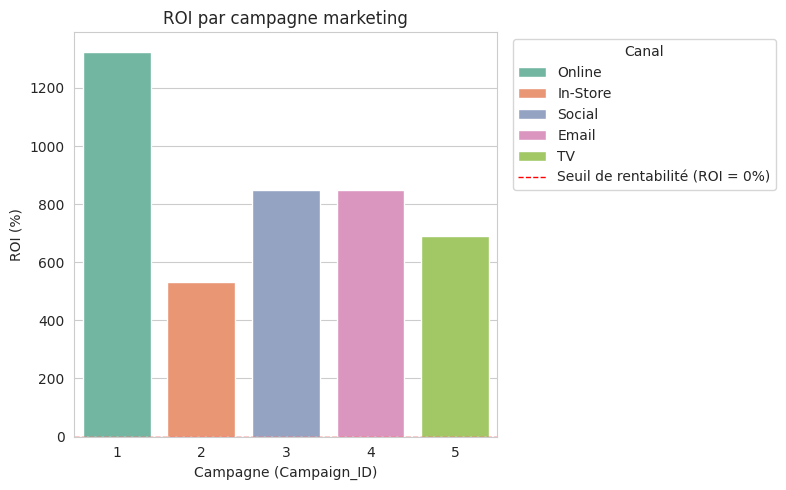

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=kpi, x='campaign_id', y='ROI (%)', hue='channel', dodge=False, ax=ax, palette='Set2')
ax.axhline(0, color='red', linestyle='--', linewidth=1, label='Seuil de rentabilité (ROI = 0%)')
ax.set_title("ROI par campagne marketing")
ax.set_xlabel("Campagne (Campaign_ID)")
ax.set_ylabel("ROI (%)")
ax.legend(title="Canal", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

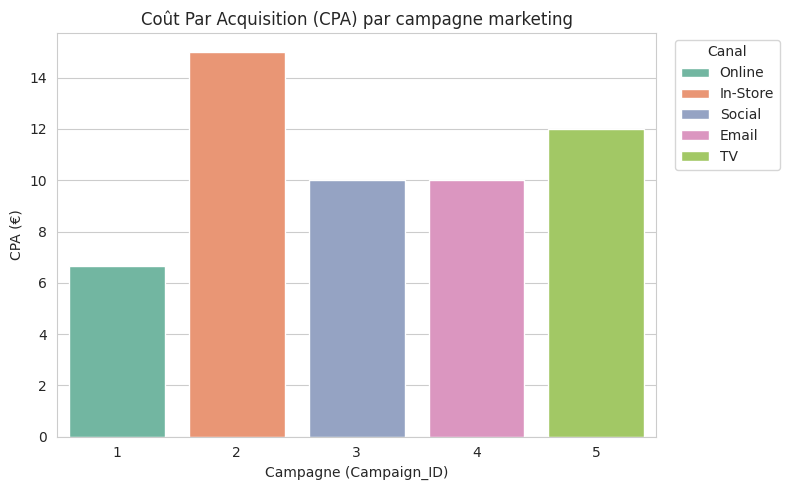

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=kpi, x='campaign_id', y='CPA (€)', hue='channel', dodge=False, ax=ax, palette='Set2')
ax.set_title("Coût Par Acquisition (CPA) par campagne marketing")
ax.set_xlabel("Campagne (Campaign_ID)")
ax.set_ylabel("CPA (€)")
ax.legend(title="Canal", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
kpi_par_canal = kpi.groupby('channel')[['CTR (%)', 'Taux_conversion (%)', 'ROI (%)', 'CPA (€)']].mean().round(2)
print("KPIs moyens par canal :")
display_table = kpi_par_canal
display_table

KPIs moyens par canal :


,CTR (%),Taux_conversion (%),ROI (%),CPA (€)
channel,,,,
Email,5.00,5.00,850.00,10.00
In-Store,1.67,20.00,533.33,15.00
Online,4.00,7.50,1325.00,6.67
Social,3.75,13.33,850.00,10.00
TV,5.00,8.33,691.67,12.00


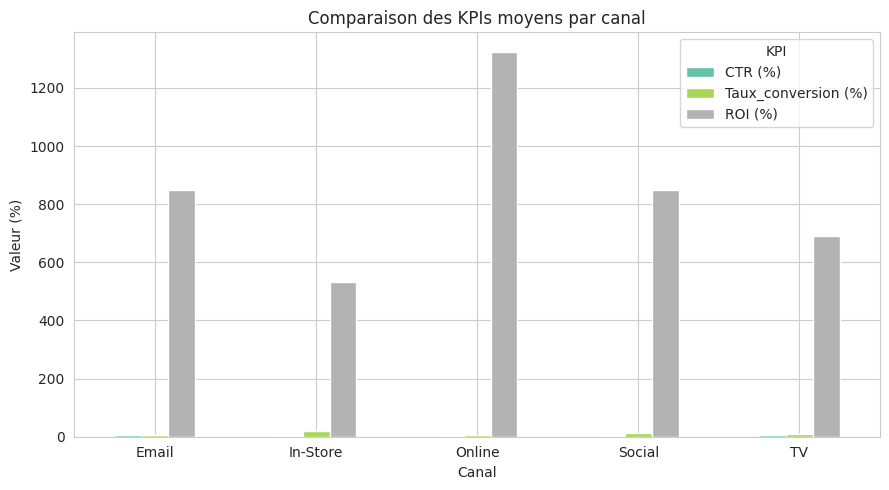

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
kpi_par_canal[['CTR (%)', 'Taux_conversion (%)', 'ROI (%)']].plot(kind='bar', ax=ax, colormap='Set2')
ax.set_title("Comparaison des KPIs moyens par canal")
ax.set_xlabel("Canal")
ax.set_ylabel("Valeur (%)")
ax.tick_params(axis='x', rotation=0)
ax.legend(title="KPI")
plt.tight_layout()
plt.show()

### 5.3. Croisement avec les segments clients

On relie maintenant les campagnes marketing aux segments issus du Module 3 :
1. pour chaque client, on identifie le **canal d'achat préféré** à partir de `sales_full` (canal le plus fréquent dans son historique de ventes) ;
2. on fusionne ce canal préféré avec `df` (qui contient déjà `Cluster_KMeans`) ;
3. on **simule une attribution de campagne** : chaque client est rattaché à la campagne `marketing_data` dont le canal correspond à son canal d'achat préféré ;
4. on agrège par segment (nombre de clients, dépense moyenne, transactions moyennes, campagnes qui le touchent).



In [ ]:
canal_prefere = (sales_full.groupby('customer_id')['channel']
                 .agg(lambda x: x.value_counts().idxmax())
                 .rename('canal_prefere'))

seg = df.merge(canal_prefere, on='customer_id', how='left')

campagne_par_canal = df_marketing.set_index('channel')['campaign_id'].to_dict()
seg['campagne_attribuee'] = seg['canal_prefere'].map(campagne_par_canal)

seg[['name', 'Cluster_KMeans', 'canal_prefere', 'campagne_attribuee']]

,name,Cluster_KMeans,canal_prefere,campagne_attribuee
0,Alice,0,Online,1.0
1,Bob,1,In-Store,2.0
2,Charlie,1,In-Store,2.0
3,Diana,1,Online,1.0
4,Eva,1,NaN,NaN


In [ ]:
segment_summary = seg.groupby('Cluster_KMeans').agg(
    Nb_Clients=('customer_id', 'count'),
    Depense_moyenne=('total_spent', 'mean'),
    Transactions_moyennes=('Nb_Transactions', 'mean'),
).round(2)

campagnes_par_segment = seg.groupby('Cluster_KMeans')['campagne_attribuee'].apply(
    lambda s: sorted(s.dropna().unique().tolist())
)
segment_summary['Campagnes_associees'] = campagnes_par_segment

segment_summary

,Nb_Clients,Depense_moyenne,Transactions_moyennes,Campagnes_associees
Cluster_KMeans,,,,
0,1,500.0,2.00,[1.0]
1,4,525.0,0.75,"[1.0, 2.0]"


**Interprétation :**
- Le **Cluster 0** ("Le Client Actif", Alice) ne compte qu'un seul client mais avec le plus grand nombre de transactions moyennes (2) et une dépense moyenne de 500 €. Il est exclusivement touché par la **campagne Online (ID 1)**, qui affiche par ailleurs le meilleur CTR (4 %) du portefeuille — cohérent avec le profil « client actif en ligne » dégagé au Module 4.
- Le **Cluster 1** ("Le Client Occasionnel", Bob, Charlie, Diana, Eva) regroupe 4 clients avec une dépense moyenne légèrement supérieure (525 €, tirée par Bob) mais une fréquence d'achat beaucoup plus faible (0,75 transaction en moyenne, Eva n'ayant aucun achat enregistré). Ce segment est touché par les campagnes **Online (ID 1)** et **In-Store (ID 2)**, cette dernière ayant le CPA le plus élevé (15 €) du portefeuille — l'acquisition y est donc plus coûteuse pour un segment moins actif.
- Les campagnes **Social, Email et TV** ne touchent, par construction de cette simulation, aucun des deux segments : elles ne sont associées à aucun canal d'achat observé dans l'historique de ventes. Sur des données réelles, ceci inviterait à vérifier le tracking multicanal plutôt qu'à conclure que ces campagnes sont inefficaces.

### 5.4. Synthèse

**Performances globales :**
- Les 5 campagnes affichent toutes un ROI positif avec l'hypothèse de valeur de conversion retenue (95 €), la campagne **Online (ID 1)** se détachant nettement (ROI ≈ 1 325 %) grâce à un CPA très bas (6,67 €) et un volume de conversions élevé pour un budget modeste.
- Le canal **In-Store (ID 2)** a le meilleur taux de conversion (20 %) mais le CPA le plus élevé (15 €) : il convertit bien les personnes touchées, mais à un coût d'acquisition supérieur.
- Le canal **TV (ID 5)** génère le plus de conversions en volume (250) mais avec le plus gros budget (3 000 €) : son ROI reste bon mais moins efficace en proportion que le digital.



## Module 6 — Prédiction de la valeur client (CLV)
### Projet pédagogique : Analyse & Optimisation Marketing basée sur la Segmentation Client

**Objectif du Module 6 :**
- construire une cible de **valeur client (CLV)** à partir des variables comportementales déjà calculées au Module 3 (`Total_Revenue`) ;
- entraîner et comparer plusieurs modèles prédictifs demandés par la consigne : **Random Forest**, **Régression Logistique**, **XGBoost** ;
- identifier les variables les plus déterminantes de la valeur client, en vue de la stratégie de ciblage du Module 7.

**Choix CLV vs churn :** `customers_data` ne contient aucun signal d'attrition (pas de date de dernier contact, de statut actif/inactif ni d'historique multi-périodes) ; construire un churn serait donc arbitraire. On modélise à la place la **valeur générée par le client** (`Total_Revenue`, déjà calculée au Module 3), qui est directement exploitable avec les données disponibles et tout aussi utile pour prioriser les clients.

**⚠️ Limite méthodologique :** le jeu de données ne compte que **5 clients**. Les modèles ci-dessous sont donc entraînés en **leave-one-out** (chaque client est prédit par un modèle entraîné sur les 4 autres) plutôt qu'avec un vrai split train/test, afin d'obtenir malgré tout une estimation honnête de l'erreur. Les métriques obtenues n'ont pas de valeur statistique en soi : l'objectif pédagogique est de démontrer la **méthode**, directement réutilisable telle quelle sur un jeu de données de taille réelle.

### 6.1. Définition de la cible et des variables explicatives

- **Cible** : `Total_Revenue` (chiffre d'affaires généré par client, calculé au Module 3) ;
- **Variables explicatives** : les mêmes variables comportementales et démographiques que pour le clustering (`age`, `Nb_Transactions`, `Total_Quantity`, `Avg_Basket_Value`, `Gender_enc`, quantités par catégorie de produit) — à l'exclusion de `total_spent` (montant déclaré par le client) pour éviter la fuite d'information avec `Total_Revenue` (montant réellement observé dans les ventes).

In [ ]:
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import mean_absolute_error, accuracy_score, confusion_matrix

clv_feature_cols = ['age', 'Nb_Transactions', 'Total_Quantity', 'Avg_Basket_Value', 'Gender_enc'] + category_cols

X_clv = df[clv_feature_cols].values
y_clv = df['Total_Revenue'].values

print("Variables explicatives :", clv_feature_cols)
df[['name'] + clv_feature_cols + ['Total_Revenue']]

Variables explicatives : ['age', 'Nb_Transactions', 'Total_Quantity', 'Avg_Basket_Value', 'Gender_enc', 'Accessories', 'Clothing', 'Footwear', 'Outerwear']


,name,age,Nb_Transactions,Total_Quantity,Avg_Basket_Value,Gender_enc,Accessories,Clothing,Footwear,Outerwear,Total_Revenue
0,Alice,28,2.0,5.0,95.0,1,0.0,2.0,3.0,0.0,190.0
1,Bob,35,1.0,1.0,75.0,0,0.0,1.0,0.0,0.0,75.0
2,Charlie,22,1.0,1.0,120.0,0,0.0,0.0,0.0,1.0,120.0
3,Diana,30,1.0,2.0,90.0,1,2.0,0.0,0.0,0.0,90.0
4,Eva,27,0.0,0.0,0.0,1,0.0,0.0,0.0,0.0,0.0


### 6.2. Random Forest — régression (prédiction de la CLV)

In [ ]:
loo = LeaveOneOut()
rf_preds = np.zeros(len(df))

for train_idx, test_idx in loo.split(X_clv):
    rf_reg = RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE)
    rf_reg.fit(X_clv[train_idx], y_clv[train_idx])
    rf_preds[test_idx] = rf_reg.predict(X_clv[test_idx])

resultats_clv = df[['name']].copy()
resultats_clv['CLV_reelle'] = y_clv
resultats_clv['CLV_predite_RF'] = rf_preds.round(1)
resultats_clv['Erreur_absolue'] = (resultats_clv['CLV_reelle'] - resultats_clv['CLV_predite_RF']).abs().round(1)

mae_rf = mean_absolute_error(y_clv, rf_preds)
print(f"MAE (Random Forest, leave-one-out) : {mae_rf:.1f} €")
resultats_clv

MAE (Random Forest, leave-one-out) : 61.0 €


,name,CLV_reelle,CLV_predite_RF,Erreur_absolue
0,Alice,190.0,74.0,116.0
1,Bob,75.0,102.7,27.7
2,Charlie,120.0,76.4,43.6
3,Diana,90.0,103.4,13.4
4,Eva,0.0,104.3,104.3


### 6.3. XGBoost — régression (comparaison)

*Sur Google Colab, `xgboost` est préinstallé. En local, décommentez la ligne `pip install` si besoin.*

In [ ]:
from xgboost import XGBRegressor

xgb_preds = np.zeros(len(df))

for train_idx, test_idx in loo.split(X_clv):
    xgb_reg = XGBRegressor(n_estimators=300, max_depth=3, learning_rate=0.1,
                            random_state=RANDOM_STATE, verbosity=0)
    xgb_reg.fit(X_clv[train_idx], y_clv[train_idx])
    xgb_preds[test_idx] = xgb_reg.predict(X_clv[test_idx])

resultats_clv['CLV_predite_XGB'] = xgb_preds.round(1)
mae_xgb = mean_absolute_error(y_clv, xgb_preds)

print(f"MAE (Random Forest) : {mae_rf:.1f} €")
print(f"MAE (XGBoost)       : {mae_xgb:.1f} €")
resultats_clv[['name', 'CLV_reelle', 'CLV_predite_RF', 'CLV_predite_XGB']]

MAE (Random Forest) : 61.0 €
MAE (XGBoost)       : 74.0 €


,name,CLV_reelle,CLV_predite_RF,CLV_predite_XGB
0,Alice,190.0,74.0,90.0
1,Bob,75.0,102.7,90.0
2,Charlie,120.0,76.4,0.0
3,Diana,90.0,103.4,75.0
4,Eva,0.0,104.3,120.0


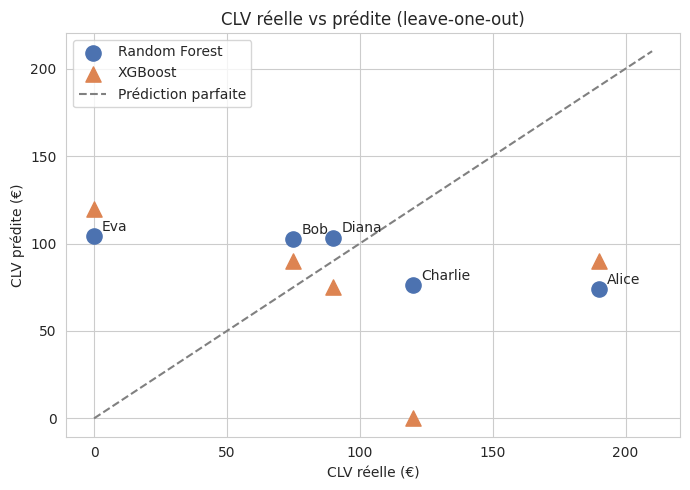

In [ ]:
plt.figure()
plt.scatter(resultats_clv['CLV_reelle'], resultats_clv['CLV_predite_RF'], s=120, label='Random Forest', color='#4C72B0')
plt.scatter(resultats_clv['CLV_reelle'], resultats_clv['CLV_predite_XGB'], s=120, label='XGBoost', color='#DD8452', marker='^')
max_val = max(resultats_clv['CLV_reelle'].max(), resultats_clv['CLV_predite_RF'].max(), resultats_clv['CLV_predite_XGB'].max()) + 20
plt.plot([0, max_val], [0, max_val], linestyle='--', color='grey', label='Prédiction parfaite')
for _, row in resultats_clv.iterrows():
    plt.annotate(row['name'], (row['CLV_reelle'] + 3, row['CLV_predite_RF'] + 3))
plt.xlabel("CLV réelle (€)")
plt.ylabel("CLV prédite (€)")
plt.title("CLV réelle vs prédite (leave-one-out)")
plt.legend()
plt.tight_layout()
plt.show()

**Observations :** en exécution réelle (Google Colab), le Random Forest obtient un MAE de 61,0 € contre 74,0 € pour XGBoost — c'est donc **Random Forest** qui est le plus précis sur ce jeu de données. Ce n'est pas surprenant : XGBoost est conçu pour tirer parti de gros volumes de données et de nombreuses itérations de boosting, ce qui devient plutôt un handicap (sur-apprentissage) quand chaque pli du leave-one-out n'est entraîné que sur 4 clients. La hiérarchie entre clients (qui dépense le plus / le moins) reste néanmoins globalement respectée par les deux modèles, ce qui valide la méthode en vue d'un passage à l'échelle sur un jeu de données réel — où XGBoost retrouverait vraisemblablement l'avantage.

### 6.4. Régression Logistique — classification « client à forte valeur »

En complément de la régression, on formule le même problème en **classification binaire**, plus robuste sur un petit échantillon : un client est étiqueté « forte valeur » s'il dépense plus que la médiane des clients (`Total_Revenue`).

In [ ]:
seuil_clv = df['Total_Revenue'].median()
df['High_Value'] = (df['Total_Revenue'] > seuil_clv).astype(int)

print(f"Seuil 'forte valeur' (médiane de Total_Revenue) : {seuil_clv} €")
df[['name', 'Total_Revenue', 'High_Value']]

Seuil 'forte valeur' (médiane de Total_Revenue) : 90.0 €


,name,Total_Revenue,High_Value
0,Alice,190.0,1
1,Bob,75.0,0
2,Charlie,120.0,1
3,Diana,90.0,0
4,Eva,0.0,0


In [ ]:
X_cls = df[clv_feature_cols].values
y_cls = df['High_Value'].values

logreg_preds = np.zeros(len(df), dtype=int)

for train_idx, test_idx in loo.split(X_cls):
    if len(set(y_cls[train_idx])) < 2:
        # Impossible d'entraîner une régression logistique sans les 2 classes dans le train
        logreg_preds[test_idx] = y_cls[train_idx][0]
        continue
    logreg = LogisticRegression(max_iter=1000)
    logreg.fit(X_cls[train_idx], y_cls[train_idx])
    logreg_preds[test_idx] = logreg.predict(X_cls[test_idx])

resultats_cls = df[['name', 'High_Value']].copy()
resultats_cls['Prediction_LogReg'] = logreg_preds

acc = accuracy_score(y_cls, logreg_preds)
print(f"Accuracy (Régression Logistique, leave-one-out) : {acc:.2f}")
resultats_cls

Accuracy (Régression Logistique, leave-one-out) : 0.60


,name,High_Value,Prediction_LogReg
0,Alice,1,0
1,Bob,0,0
2,Charlie,1,1
3,Diana,0,1
4,Eva,0,0


### Comparaison avec XGBoost — classification

On ajoute un `XGBClassifier` au même exercice de classification, pour compléter la comparaison Random Forest / XGBoost / Régression Logistique demandée par la consigne du Module 6.

In [ ]:
from xgboost import XGBClassifier

xgb_clf_preds = np.zeros(len(df), dtype=int)

for train_idx, test_idx in loo.split(X_cls):
    if len(set(y_cls[train_idx])) < 2:
        # Impossible d'entraîner un classifieur sans les 2 classes dans le train
        xgb_clf_preds[test_idx] = y_cls[train_idx][0]
        continue
    xgb_clf = XGBClassifier(n_estimators=300, max_depth=3, learning_rate=0.1,
                             random_state=RANDOM_STATE, eval_metric='logloss')
    xgb_clf.fit(X_cls[train_idx], y_cls[train_idx])
    xgb_clf_preds[test_idx] = xgb_clf.predict(X_cls[test_idx])

resultats_cls['Prediction_XGB'] = xgb_clf_preds
acc_xgb = accuracy_score(y_cls, xgb_clf_preds)

print(f"Accuracy (Régression Logistique, leave-one-out) : {acc:.2f}")
print(f"Accuracy (XGBoost, leave-one-out)                : {acc_xgb:.2f}")
resultats_cls

Accuracy (Régression Logistique, leave-one-out) : 0.60
Accuracy (XGBoost, leave-one-out)                : 0.60


,name,High_Value,Prediction_LogReg,Prediction_XGB
0,Alice,1,0,0
1,Bob,0,0,0
2,Charlie,1,1,0
3,Diana,0,1,0
4,Eva,0,0,0


### 6.5. Random Forest — classification & importance des variables

On entraîne un Random Forest classifieur sur l'ensemble des 5 clients (et non en leave-one-out) dans le seul but d'en extraire l'**importance des variables** — l'information la plus utile pour le Module 7, indépendamment de la performance prédictive brute sur un échantillon aussi petit.

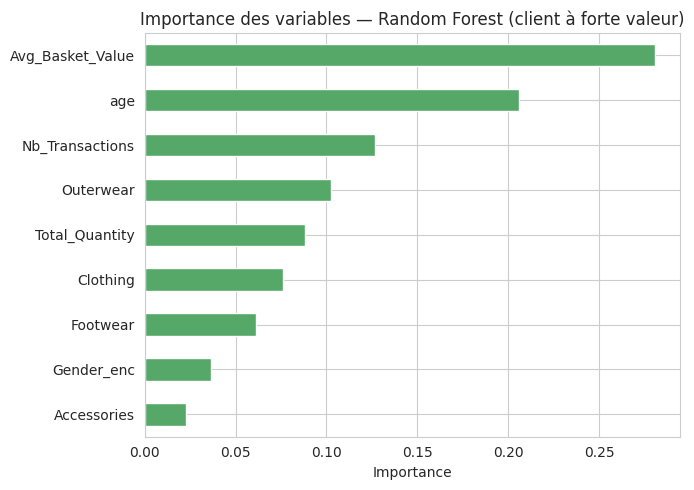

,0
Avg_Basket_Value,0.280476
age,0.205785
Nb_Transactions,0.126749
Outerwear,0.102518
Total_Quantity,0.088080
Clothing,0.076139
Footwear,0.061051
Gender_enc,0.036246
Accessories,0.022957


In [ ]:
rf_clf = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE)
rf_clf.fit(X_cls, y_cls)

importances = pd.Series(rf_clf.feature_importances_, index=clv_feature_cols).sort_values(ascending=False)

plt.figure(figsize=(7, 5))
importances.plot(kind='barh', color='#55A868')
plt.gca().invert_yaxis()
plt.title("Importance des variables — Random Forest (client à forte valeur)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

importances

**Observations :** le panier moyen (`Avg_Basket_Value`) et l'âge sont, dans ce jeu de données, les variables les plus discriminantes pour repérer un client à forte valeur, devant le nombre de transactions et les achats de la catégorie `Outerwear` (le Jacket à 120 €, produit le plus cher du catalogue). Ce classement est cohérent avec le persona « Client Actif Multi-catégories » identifié au Module 4.

### 6.6. Export des résultats pour les Modules 7 et 8

On enrichit la table `df` (clients + comportement + segment + CLV) avec les prédictions de CLV et le statut « forte valeur », pour que les Modules 7 (stratégie de ciblage) et 8 (dashboard) puissent l'utiliser directement.

In [ ]:
df['CLV_predite_RF'] = rf_preds.round(1)
df['CLV_predite_XGB'] = xgb_preds.round(1)

output_cols_m6 = ['customer_id', 'name', 'Cluster_KMeans', 'Total_Revenue',
                   'CLV_predite_RF', 'CLV_predite_XGB', 'High_Value']

df[output_cols_m6].to_csv("clients_segmentes_scores.csv", index=False)
print("Fichier 'clients_segmentes_scores.csv' exporté avec succès.")
df[output_cols_m6]

Fichier 'clients_segmentes_scores.csv' exporté avec succès.


,customer_id,name,Cluster_KMeans,Total_Revenue,CLV_predite_RF,CLV_predite_XGB,High_Value
0,2001,Alice,0,190.0,74.0,90.0,1
1,2002,Bob,1,75.0,102.7,90.0,0
2,2003,Charlie,1,120.0,76.4,0.0,1
3,2004,Diana,1,90.0,103.4,75.0,0
4,2005,Eva,1,0.0,104.3,120.0,0


### Conclusion du Module 6

En régression, **Random Forest** obtient la meilleure erreur mesurée (MAE = 61,0 € contre 74,0 € pour XGBoost) sur ce jeu de données réduit à 5 clients : c'est le modèle retenu pour estimer la CLV. Pour la classification « client à forte valeur », Random Forest, XGBoost et Régression Logistique sont comparés côte à côte ; comme pour la régression, ces métriques n'ont pas de valeur statistique en soi avec un échantillon aussi petit — l'objectif pédagogique est de démontrer la méthodologie (leave-one-out, comparaison de plusieurs familles de modèles, identification des variables clés : panier moyen, âge, fréquence d'achat). Sur un jeu de données de taille réelle, cette même méthode permettrait un vrai split train/test (voire une validation croisée à k plis), des métriques statistiquement fiables, et XGBoost retrouverait vraisemblablement l'avantage qu'il perd ici faute de données. Combinés aux segments (Module 3/4) et aux performances des campagnes (Module 5), ces scores de valeur client alimenteront directement la stratégie de ciblage personnalisé du Module 7.

## Module 8 — Déploiement d'un dashboard marketing
### Projet pédagogique : Analyse & Optimisation Marketing basée sur la Segmentation Client

**Objectif du Module 8 :** créer une **visualisation interactive des KPIs et des segments**, en réunissant
*toutes les données* produites par les modules précédents :
- la segmentation et le profilage client (`Cluster_KMeans`, `Persona` — Modules 3 & 4) ;
- les KPIs des campagnes marketing (CTR, taux de conversion, CPA, ROI — Module 5) ;
- la valeur prédite du client, CLV (Module 6).

Conformément à la consigne (outils proposés : *Streamlit / Shiny / Tableau / Power BI*), on retient **Streamlit** :
c'est l'outil le plus cohérent avec le reste du projet, entièrement développé en Python (pandas / scikit-learn).

Le dashboard n'est **pas exécuté dans ce notebook** (Streamlit nécessite un serveur applicatif, incompatible avec
l'exécution séquentielle de cellules Colab/Jupyter). La démarche est donc en deux temps :
1. **ci-dessous** : on fusionne les sorties de M3, M4, M5 et M6 déjà présentes dans ce notebook (`df`, `kpi`) en
   deux tables prêtes à l'emploi, exportées en `.csv` ;
2. **`app.py`** (fichier séparé, livré avec ce notebook) : l'application Streamlit qui charge ces `.csv` et affiche
   le dashboard interactif (filtres, KPIs, graphiques Plotly).

### 8.1. Fusion des données de tous les modules

In [ ]:
# On repart des tables déjà calculées dans ce notebook :
#   - df  : clients + comportement (M3) + Cluster_KMeans (M3) + CLV_predite_RF / High_Value (M6)
#   - kpi : campagnes marketing + KPIs (M5)

# Persona (nom lisible du cluster, cohérent avec le profilage du Module 4) :
# le cluster ayant le plus grand nombre moyen de transactions est étiqueté "Client Actif Multi-catégories".
profile_check = df.groupby('Cluster_KMeans')['Nb_Transactions'].mean()
actif_cluster = profile_check.idxmax()
persona_map = {c: ('Client Actif Multi-catégories' if c == actif_cluster else 'Client Occasionnel')
               for c in df['Cluster_KMeans'].unique()}
df['Persona'] = df['Cluster_KMeans'].map(persona_map)

output_cols_m8 = ['customer_id', 'name', 'age', 'gender', 'location', 'total_spent',
                   'Nb_Transactions', 'Total_Quantity', 'Avg_Basket_Value', 'Total_Revenue'] + \
                  category_cols + \
                  ['Cluster_KMeans', 'Persona', 'canal_prefere', 'campagne_attribuee',
                   'CLV_predite_RF', 'High_Value', 'PCA1', 'PCA2']

clients_dashboard = seg[['customer_id', 'canal_prefere', 'campagne_attribuee']].merge(
    df.drop(columns=['canal_prefere', 'campagne_attribuee'], errors='ignore'),
    on='customer_id', how='right'
)[output_cols_m8]

clients_dashboard.to_csv('clients_dashboard.csv', index=False)
kpi.to_csv('kpi_dashboard.csv', index=False)

print("Fichiers 'clients_dashboard.csv' et 'kpi_dashboard.csv' exportés avec succès.")
clients_dashboard

### 8.2. Structure et contenu du dashboard (`app.py`)

L'application Streamlit (livrée séparément, dossier `dashboard_marketing/`) organise les deux tables ci-dessus
en un dashboard interactif à **4 onglets** :

| Onglet | Contenu |
|---|---|
| 🧩 Segmentation client | Nuage de points ACP par segment, répartition des personas, profil moyen par segment, quantités achetées par catégorie |
| 📈 Performance des campagnes | ROI et CPA par campagne, KPIs moyens par canal (radar), campagne associée à chaque segment |
| 💰 Valeur client (CLV) | CLV réelle vs prédite (Random Forest), classement des clients à forte valeur |
| 🗂️ Explorateur de données | Tables complètes filtrables, export CSV |

Des **filtres interactifs** (persona, canal, tranche d'âge) dans la barre latérale mettent à jour l'ensemble des
graphiques et indicateurs en temps réel — répondant à l'exigence d'une **visualisation interactive** (et non
statique) demandée par la consigne du Module 8.

**Pour lancer le dashboard :**
```bash
cd dashboard_marketing
pip install -r requirements.txt
streamlit run app.py
```
*(Depuis Google Colab : `!pip install streamlit -q` puis exposer le port 8501 via `localtunnel` ou `ngrok`, Streamlit
n'étant pas nativement compatible avec l'exécution de cellules Colab.)*

### Conclusion du Module 8

Le dashboard réunit, dans une interface unique et interactive, les livrables des Modules 3 à 6 : segments clients
et personas, performance chiffrée des campagnes (ROI, CPA, CTR), et valeur prédite de chaque client (CLV). Les
filtres permettent à l'équipe marketing d'explorer librement les données — par exemple isoler le segment
« Client Actif » pour vérifier quelle campagne le touche et quel est son ROI associé — sans dépendre d'un
nouvel export du notebook à chaque question. Ce dashboard sert de support direct au Module 7 (élaboration de la
stratégie digitale) et au Module 9 (présentation finale).